# Acoustic plots

This tutorial was prepared by Alexandre Olender olender@usp.br

This tutorial demonstrates Spiro's plotting utilities in the acoustic wave problem. We will plot:
1. A high-resolution velocity model;
2. Wavefield solved at a given timestep;
3. An individual receiver trace;
4. A complete shot record.

In [1]:
# Code in this cell enables plotting in the notebook
%matplotlib inline

import spyro
import numpy as np

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified



Let us begin by setting up a spiro forward problem that models the acoustic wave progation in a Camembert velocity model.

In [2]:
dictionary = {}
dictionary["camembert_options"] = {
    "radius": 0.2,
    "circle_center": (-1.0, 1.0),
    "outside_velocity": 2.5,
    "inside_circle_velocity": 3.0,
}
dictionary["mesh"] = {
    "length_z": 2.0, "length_x": 2.0,
    "h": 0.1,  # mesh size in km
    "mesh_type": "firedrake_mesh",
}
dictionary["acquisition"] = {
    "source_type": "ricker",
    "source_locations": [(-0.55, 1.0)],
    "frequency": 5.0,
    "delay": 0.2,
    "delay_type": "time",
    "receiver_locations": spyro.create_transect((-1.45, 0.7), (-1.45, 1.3), 200),
    "use_vertex_only_mesh": True,
}
dictionary["time_axis"] = {
    "final_time": 0.8,  # Final time for event
    "dt": 1e-3,  # timestep size
    "amplitude": 1,  # the Ricker wave has an amplitude of 1.
    "gradient_sampling_frequency": 1,  # how frequently to save solution to RAM
}
dictionary["absorving_boundary_conditions"] = {
    "status": True,  # True or false
}
wave = spyro.examples.Camembert_acoustic(dictionary=dictionary)
wave.store_forward_time_steps = True  # For visualization purposes this will save the propagation solution at the gradient sampling frequency.
wave.forward_solve()


Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.
Mesh Created with 441 Nodes and 800 Area Elements


/workspaces/elastic/spyro/solvers/wave.py:166: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(



Solving Forward Problem
Saving Pressure in: results/camembert_forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds


## High resolution velocity model
We can have a look at our velocity model that's actually been usedfor the wave propagation.

Because `wave.c` is represented using high-order finite elements, directly plotting the function with Firedrake's standard plotting utilities does not provide the same high-resolution visualization of the underlying higher-order field. Spiro's `export_scalar_field` evaluates the field on a user-defined resolution before generating the image.

/usr/local/lib/python3.12/dist-packages/segyio/utils.py:18: RuntimeWarning: Implicit conversion to contiguous array
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/segyio/utils.py:23: RuntimeWarning: Implicit conversion from float64 to float32 (narrowing)
  warnings.warn(msg.format(x.dtype, dtype), RuntimeWarning)


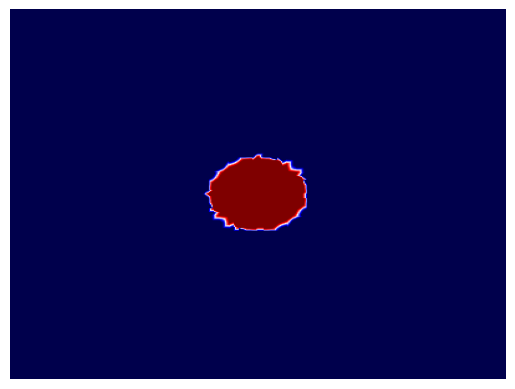

In [3]:
resolution = 0.005
spyro.io.export_scalar_field(wave.c, resolution, "camembert.png", comm=wave.comm, show=True)

For comparison, we can plot the same field using Firedrake's standard plotting functionality (which is a matplolib wrapper):

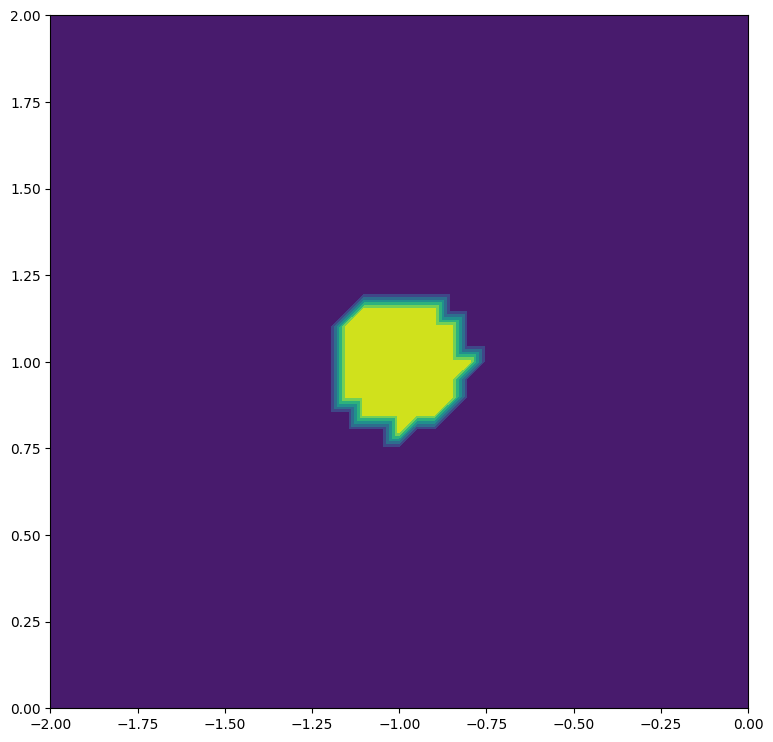

In [4]:
import matplotlib.pyplot as plt
from firedrake import tricontourf
fig, axes = plt.subplots(figsize=(9, 9))
tricontourf(wave.c, axes=axes)

## Visualizing the wavefield

Because we enabled `store_forward_time_steps`, the forward wavefield is
available for visualization after the simulation.

`wave.u_n` contains the wavefield at the current time, which for our finished simulation would be the final time.

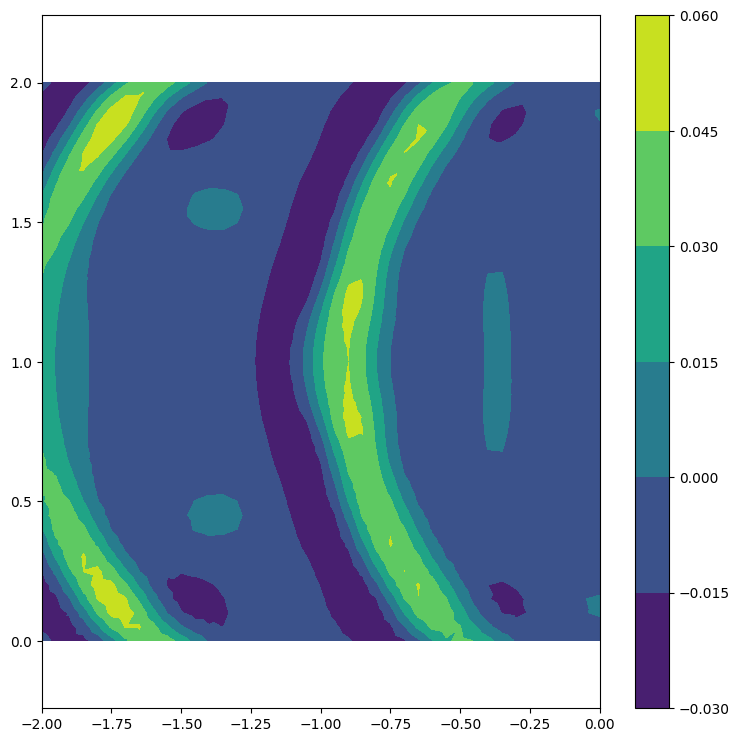

In [5]:
last_pressure = wave.u_n
spyro.plots.plot_function(last_pressure)

## Visualizing a receiver trace

This result looks a bit weird. Could it be that most of the wave has allready left our domain and we are looking only at the minor non basorbed reflections? To check, we can also have a look at our receiver response. For the acoustic wave the receivers measure pressure values. The receiver data is stored in a NumPy array with shape (NT, NR), where NT is the number of stored time steps and NR is the number of receivers. To select all the timesteps for receiver 100 and plot:

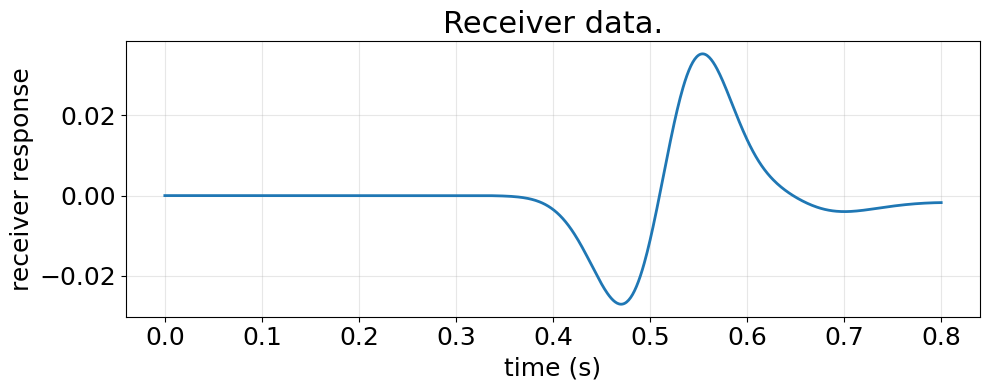

In [6]:
spyro.plots.plot_receiver_response(wave.forward_solution_receivers[:, 100], final_time=0.8, show=True)

## Generating a shot record

Let us also look at our shot record, where the direct wave is very visible. The shot record contains the receiver responses for the complete simulation. It allows us to visualize the propagation of the wavefield.

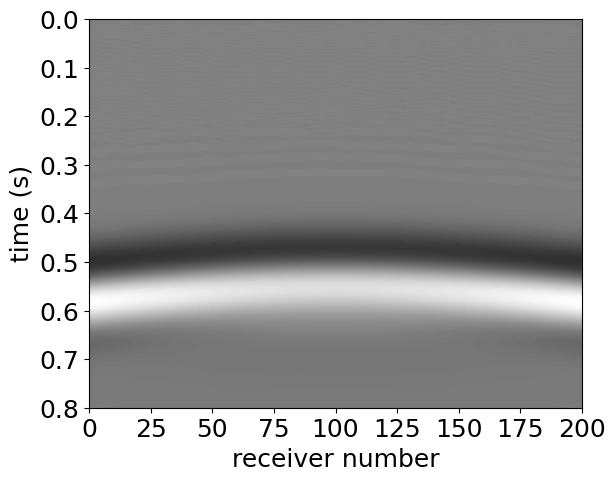

In [7]:
pressure_max = np.max(wave.forward_solution_receivers)
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-pressure_max, vmax=pressure_max, show=True)

We can notice that the wave front hits the receiver 100 at around 0.5 seconds. Let us check how our wavfield looks at that time.

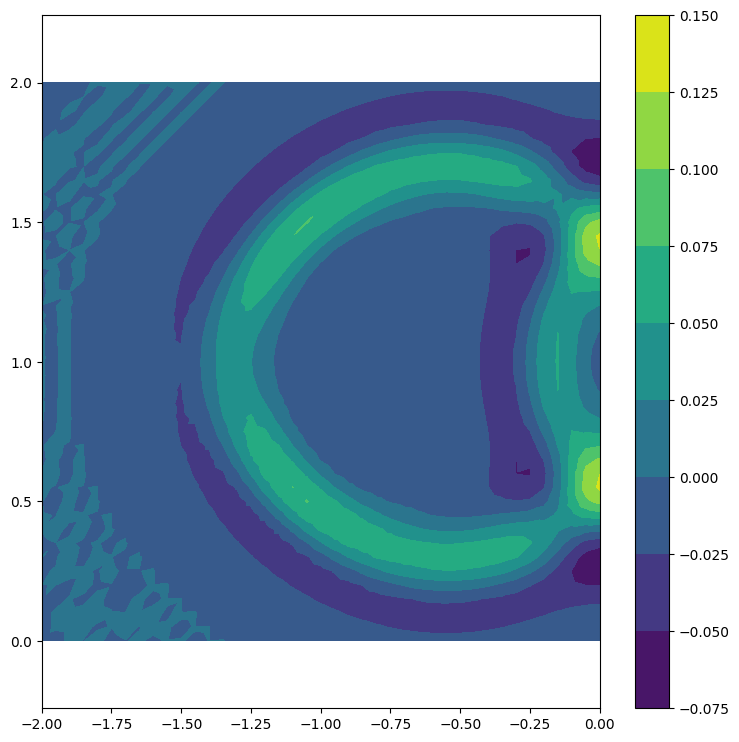

In [9]:
time = 0.5
time_index = round(time / dictionary["time_axis"]["dt"]) + 1
pressure_at_half_a_second = wave.forward_solution[time_index]
spyro.plots.plot_function(pressure_at_half_a_second)